In [11]:
#Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [15]:
#Carregando os dados
dataset=pd.read_csv('dataset.csv')

In [19]:
#Shape
#Quantidade de linhas e colunas
dataset.shape

(2938, 22)

In [25]:
#Tipos de dados
dataset.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
 Population                        float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [27]:
#Amostra dos dados
dataset.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1847,New Zealand,2013,Developed,81.3,69.0,0,9.18,10019.076300,93.0,8,...,92.0,11.17,92.0,0.1,42889.881410,NaN,0.3,0.3,0.908,19.3
1203,Indonesia,2014,Developing,68.9,179.0,119,0.09,200.068444,78.0,12943,...,8.0,2.85,78.0,0.3,3491.595887,255131116.0,1.4,1.2,0.682,12.9
874,Estonia,2007,Developing,73.0,189.0,0,17.87,1904.124690,95.0,1,...,95.0,5.16,95.0,0.1,16586.452000,13468.0,2.0,2.1,0.829,16.1
1077,Guinea,2012,Developing,58.4,288.0,28,0.01,4.344931,62.0,6,...,63.0,5.39,62.0,1.9,52.348565,11281469.0,7.8,7.8,0.396,8.5
50,Angola,2013,Developing,51.1,355.0,69,8.10,35.958573,77.0,8523,...,67.0,4.26,77.0,2.3,484.616884,2599834.0,8.6,8.5,0.523,11.4
1017,Ghana,2008,Developing,63.0,275.0,41,1.78,161.010643,93.0,82,...,92.0,4.85,93.0,2.2,1224.415540,2329864.0,7.5,7.4,0.530,9.8
890,Ethiopia,2007,Developing,58.5,39.0,186,1.06,30.464518,47.0,1446,...,61.0,4.69,5.0,2.8,243.326822,8149.0,11.3,11.0,0.362,7.1
2315,Singapore,2013,Developed,82.7,57.0,0,1.83,714.344102,97.0,138,...,97.0,4.53,97.0,0.1,5629.189140,NaN,2.2,2.2,0.920,15.4
608,Congo,2015,Developing,64.7,267.0,7,NaN,0.000000,8.0,1359,...,8.0,NaN,8.0,2.8,NaN,NaN,7.5,7.1,0.590,11.1
1139,Honduras,2014,Developing,74.5,149.0,3,2.87,345.377634,97.0,0,...,97.0,8.72,97.0,0.3,2242.711912,889216.0,2.1,2.1,0.618,11.4


In [31]:
#Colunas
dataset.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', ' Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [33]:
#Criando um novo dataset e ajustando o nome das variaveis
#Estamos desconsiderando algumas variáveis pois não sao claras na fonte de dados
df = pd.DataFrame({'country': dataset['Country'],
                   'life_expectancy': dataset['Life expectancy '],
                   'year': dataset['Year'],
                   'status': dataset['Status'],
                   'adult_mortality': dataset['Adult Mortality'],
                   'inf_death': dataset['infant deaths'],
                   'alcohol': dataset['Alcohol'],
                   'hepatitisB': dataset['Hepatitis B'],
                   'measles': dataset['Measles '],
                   'bmi': dataset[' BMI '],
                   'polio': dataset['Polio'],
                   'diphtheria': dataset['Diphtheria '],
                   'hiv': dataset[' HIV/AIDS'],
                   'gdp': dataset['GDP'],
                   'total_expenditure': dataset['Total expenditure'],
                   'thinness_till19': dataset[' thinness  1-19 years'],
                   'thinness_till9': dataset[' thinness 5-9 years'],
                   'school': dataset['Schooling'],
                   'population': dataset[' Population']})

In [35]:
#Tipos de dados
df.dtypes

country               object
life_expectancy      float64
year                   int64
status                object
adult_mortality      float64
inf_death              int64
alcohol              float64
hepatitisB           float64
measles                int64
bmi                  float64
polio                float64
diphtheria           float64
hiv                  float64
gdp                  float64
total_expenditure    float64
thinness_till19      float64
thinness_till9       float64
school               float64
population           float64
dtype: object

In [37]:
#shape
df.shape

(2938, 19)

In [39]:
#Dataset
df.head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
0,Afghanistan,65.0,2015,Developing,263.0,62,0.01,65.0,1154,19.1,6.0,65.0,0.1,584.259210,8.16,17.2,17.3,10.1,33736494.0
1,Afghanistan,59.9,2014,Developing,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0
2,Afghanistan,59.9,2013,Developing,268.0,66,0.01,64.0,430,18.1,62.0,64.0,0.1,631.744976,8.13,17.7,17.7,9.9,31731688.0
3,Afghanistan,59.5,2012,Developing,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0
4,Afghanistan,59.2,2011,Developing,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0


In [41]:
#Dicionario de dados
data_df_dict = {
    "country": "País de origem dos dados.",
    "life_expectancy": "Expectativa de vida ao nascer, em anos.",
    "year": "Ano em que os dados foram coletados.",
    "status": "Status de desenvolvimento do país ('Developing' para países em desenvolvimento, 'Developed' para países desenvolvidos).",
    "adult_mortality": "Taxa de mortalidade de adultos entre 15 e 60 anos por 1000 habitantes.",
    "inf_death": "Número de mortes de crianças com menos de 5 anos por 1000 nascidos vivos.",
    "alcohol": "Consumo de álcool per capita (litros de álcool puro por ano).",
    "hepatitisB": "Cobertura de vacinação contra hepatite B em crianças de 1 ano (%).",
    "measles": "Número de casos de sarampo relatados por 1000 habitantes.",
    "bmi": "Índice médio de massa corporal da população adulta.",
    "polio": "Cobertura de vacinação contra poliomielite em crianças de 1 ano (%).",
    "diphtheria": "Cobertura de vacinação contra difteria, tétano e coqueluche (DTP3) em crianças de 1 ano (%).",
    "hiv": "Prevalência de HIV na população adulta (%).",
    "gdp": "Produto Interno Bruto per capita (em dólares americanos).",
    "total_expenditure": "Gasto total em saúde como porcentagem do PIB.",
    "thinness_till19": "Prevalência de magreza em crianças e adolescentes de 10 a 19 anos (%).",
    "thinness_till9": "Prevalência de magreza em crianças de 5 a 9 anos (%).",
    "school": "Número médio de anos de escolaridade.",
    "population": "População total do país."
}

In [43]:
#Consulta
data_df_dict['life_expectancy']

'Expectativa de vida ao nascer, em anos.'

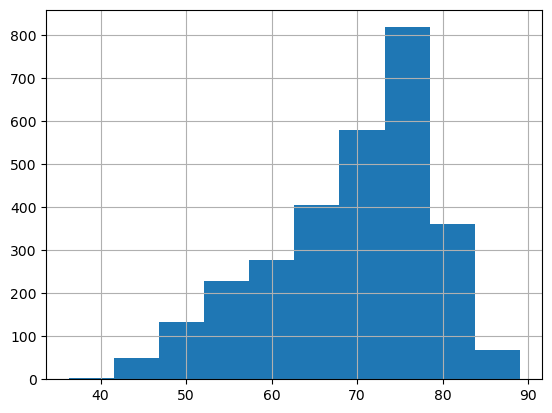

In [45]:
#Histograma da variavel alvo
df['life_expectancy'].hist();

In [47]:
#Resumo estatistico das variaveis numéricas
df.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2928.000000,2938.000000,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2919.000000,2938.000000,2490.000000,2712.00000,2904.000000,2904.000000,2775.000000,2.286000e+03
mean,69.224932,2007.518720,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,82.324084,1.742103,7483.158469,5.93819,4.839704,4.870317,11.992793,1.275338e+07
std,9.523867,4.613841,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,23.716912,5.077785,14270.169342,2.49832,4.420195,4.508882,3.358920,6.101210e+07
min,36.300000,2000.000000,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,2.000000,0.100000,1.681350,0.37000,0.100000,0.100000,0.000000,3.400000e+01
25%,63.100000,2004.000000,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,78.000000,0.100000,463.935626,4.26000,1.600000,1.500000,10.100000,1.957932e+05
50%,72.100000,2008.000000,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,93.000000,0.100000,1766.947595,5.75500,3.300000,3.300000,12.300000,1.386542e+06
75%,75.700000,2012.000000,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,97.000000,0.800000,5910.806335,7.49250,7.200000,7.200000,14.300000,7.420359e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.870000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.600000,119172.741800,17.60000,27.700000,28.600000,20.700000,1.293859e+09


In [49]:
#Resumo estatístico para variáveis categóricas
df.describe(include=['object'])

,country,status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [53]:
#Visualizando o total de linhas por coluna
#Temos valores diferentes nas categorias
df.count()

country              2938
life_expectancy      2928
year                 2938
status               2938
adult_mortality      2928
inf_death            2938
alcohol              2744
hepatitisB           2385
measles              2938
bmi                  2904
polio                2919
diphtheria           2919
hiv                  2938
gdp                  2490
total_expenditure    2712
thinness_till19      2904
thinness_till9       2904
school               2775
population           2286
dtype: int64

In [55]:
#Total de valores ausentes por coluna
valores_ausentes = df.isnull().sum().sort_values(ascending = False)

In [59]:
#Valores ausentes
print(valores_ausentes)

population           652
hepatitisB           553
gdp                  448
total_expenditure    226
alcohol              194
school               163
thinness_till9        34
thinness_till19       34
bmi                   34
polio                 19
diphtheria            19
life_expectancy       10
adult_mortality       10
hiv                    0
measles                0
inf_death              0
status                 0
year                   0
country                0
dtype: int64


In [61]:
#Calculando o percentual de valores ausentes
#Shape [0] é o número de linhas
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / df.shape[0]

In [63]:
print(f'{valores_ausentes_percent * 100} %')

population           22.191967
hepatitisB           18.822328
gdp                  15.248468
total_expenditure     7.692308
alcohol               6.603131
school                5.547992
thinness_till9        1.157250
thinness_till19       1.157250
bmi                   1.157250
polio                 0.646698
diphtheria            0.646698
life_expectancy       0.340368
adult_mortality       0.340368
dtype: float64 %


In [65]:
#Atributos com mais de 5% de valores ausentes
atributos = ['population', 'hepatitisB', 'gdp', 'total_expenditure', 'alcohol', 'school']

In [67]:
#Cria um novo dataframe
novo_dataframe = df[atributos]

In [69]:
#Identificação de outliers através do método do IQR(Interquartile Range)
Q1 = novo_dataframe.quantile(0.25)
Q3 = novo_dataframe.quantile(0.75)
IQR = Q3 - Q1

In [71]:
#Definir outliers como aqueles valores que estão fora do intervalo [ Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]
outliers = ((novo_dataframe < (Q1 - 1.5 * IQR)) | (novo_dataframe > (Q3 + 1.5 * IQR))).sum()

In [73]:
#Total de outliers
outliers

population           294
hepatitisB           254
gdp                  365
total_expenditure     32
alcohol                0
school                44
dtype: int64

In [75]:
# Cria um resumo com os outliers
outliers_summary = pd.DataFrame({'Outliers':outliers, 'Percentual': (outliers / len(novo_dataframe)) * 100})

In [77]:
#Retorna os resultados quando o valor for maior do zero
outliers_summary[outliers_summary['Outliers'] > 0]

,Outliers,Percentual
population,294,10.006807
hepatitisB,254,8.645337
gdp,365,12.423417
total_expenditure,32,1.089176
school,44,1.497617


In [ ]:
#Análise estatística para tratamento de outliers